# Transformation to C Code (Simple)

## Imports

In [1]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np

from zoomy_core.model.models.shallow_water import ShallowWaterEquations as SWE
from zoomy_core.model.models.shallow_water_topo import NumericalShallowWaterEquationsWithTopo 
from zoomy_core.model.models.shallow_moments_topo import NumericalShallowMomentsTopo, ShallowMomentsTopo

import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct, Settings
from zoomy_core.transformation.to_c import CppModel, CppNumerics
import zoomy_core.misc.misc as misc
from zoomy_core.model.custom_sympy_functions import conditional



## Model definition

In [ ]:
bcs = BC.BoundaryConditions(
    [
        BC.Extrapolation(tag="wall"),
        BC.Extrapolation(tag="inflow"),
        BC.Extrapolation(tag="outflow"),
    ]
)

class SMEB(NumericalShallowMomentsTopo):
    
    def initial_condition(self):
        X = self.position
        p = self.parameters
        out = misc.ZArray.zeros(self.n_variables)
        out[0] = 1.
        out[1] = conditional(X[0] < 5, 2., 0.)
        return out

    def initial_aux_condition(self):
        X = self.position
        p = self.parameters
        eps = p.eps
        out = misc.ZArray.zeros(self.n_aux_variables)
        out[0] = conditional(X[0] < 5, 1./2., 1./eps)
        return out
    
    
    def update_aux_variables(self):
        Q = self.variables
        Qaux = misc.ZArray(self.aux_variables)
        eps = self.parameters.eps
        Qaux[0] = Q[1] / (Q[1]**2 + eps)
        return misc.ZArray(Qaux)
    
    

model = SMEB(
    level=1 ,
    dimension=2,
    boundary_conditions=bcs,
    aux_variables=1,
)


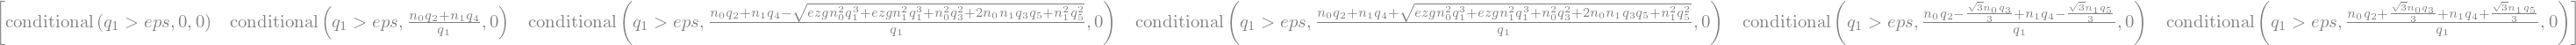

In [3]:
model.functions.eigenvalues.definition

## Sympy Model

In [4]:
import sympy as sp

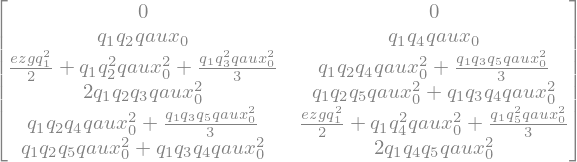

In [5]:
model.flux()

In [6]:
model.functions.flux.args

Zstruct(variables=Zstruct(q0=q0, q1=q1, q2=q2, q3=q3, q4=q4, q5=q5), aux_variables=Zstruct(qaux0=qaux0), p=Zstruct(g=g, chezy_C=chezy_C, eps=eps, ex=ex, ey=ey, ez=ez, rho=rho, nu=nu, lamda=lamda, c_slipmod=c_slipmod, l_bl=l_bl, l_turb=l_turb, kappa=kappa))

In [7]:
print(model.call.flux())

[[0, 0], [q1*q2*qaux0, q1*q4*qaux0], [ez*g*q1**2/2 + q1*q2**2*qaux0**2 + q1*q3**2*qaux0**2/3, q1*q2*q4*qaux0**2 + q1*q3*q5*qaux0**2/3], [2*q1*q2*q3*qaux0**2, q1*q2*q5*qaux0**2 + q1*q3*q4*qaux0**2], [q1*q2*q4*qaux0**2 + q1*q3*q5*qaux0**2/3, ez*g*q1**2/2 + q1*q4**2*qaux0**2 + q1*q5**2*qaux0**2/3], [q1*q2*q5*qaux0**2 + q1*q3*q4*qaux0**2, 2*q1*q4*q5*qaux0**2]]


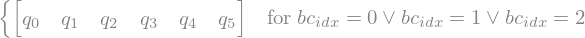

In [8]:
model.print_boundary_conditions()

## Code transformation

In [9]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/trafo", filename="swe.h5", clean_directory=True, snapshots=30))
CppModel.write_code(model, settings)


'/home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H'

In [10]:
! cp /home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H /home/ingo/Git/Zoomy/library/zoomy_dmplex

In [11]:
from zoomy_core.fvm.symbolic_numerics import PositiveRusanov, Rusanov, QuasilinearRusanov, PositiveQuasilinearRusanov

In [12]:
# numerics = PositiveRusanov(model)
# numerics = Rusanov(model)

numerics = PositiveQuasilinearRusanov(model)

In [13]:
print(model.flux())
print(model.call.flux())

[[0, 0], [q1*q2*qaux0, q1*q4*qaux0], [ez*g*q1**2/2 + q1*q2**2*qaux0**2 + q1*q3**2*qaux0**2/3, q1*q2*q4*qaux0**2 + q1*q3*q5*qaux0**2/3], [2*q1*q2*q3*qaux0**2, q1*q2*q5*qaux0**2 + q1*q3*q4*qaux0**2], [q1*q2*q4*qaux0**2 + q1*q3*q5*qaux0**2/3, ez*g*q1**2/2 + q1*q4**2*qaux0**2 + q1*q5**2*qaux0**2/3], [q1*q2*q5*qaux0**2 + q1*q3*q4*qaux0**2, 2*q1*q4*q5*qaux0**2]]
[[0, 0], [q1*q2*qaux0, q1*q4*qaux0], [ez*g*q1**2/2 + q1*q2**2*qaux0**2 + q1*q3**2*qaux0**2/3, q1*q2*q4*qaux0**2 + q1*q3*q5*qaux0**2/3], [2*q1*q2*q3*qaux0**2, q1*q2*q5*qaux0**2 + q1*q3*q4*qaux0**2], [q1*q2*q4*qaux0**2 + q1*q3*q5*qaux0**2/3, ez*g*q1**2/2 + q1*q4**2*qaux0**2 + q1*q5**2*qaux0**2/3], [q1*q2*q5*qaux0**2 + q1*q3*q4*qaux0**2, 2*q1*q4*q5*qaux0**2]]


In [14]:
print(numerics.numerical_flux())
print(numerics.call.numerical_flux())

[0.5*n0*Model<T>::flux([Max(Q_minus_0, Q_plus_0), Max(0.0, Q_minus_0 + Q_minus_1 - Max(Q_minus_0, Q_plus_0)), Q_minus_2*Max(0.0, Q_minus_0 + Q_minus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_minus_1), Q_minus_3*Max(0.0, Q_minus_0 + Q_minus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_minus_1), Q_minus_4*Max(0.0, Q_minus_0 + Q_minus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_minus_1), Q_minus_5*Max(0.0, Q_minus_0 + Q_minus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_minus_1)], Qaux_minus, [g, chezy_C, eps, ex, ey, ez, rho, nu, lamda, c_slipmod, l_bl, l_turb, kappa])[0] + 0.5*n0*Model<T>::flux([Max(Q_minus_0, Q_plus_0), Max(0.0, Q_plus_0 + Q_plus_1 - Max(Q_minus_0, Q_plus_0)), Q_plus_2*Max(0.0, Q_plus_0 + Q_plus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_plus_1), Q_plus_3*Max(0.0, Q_plus_0 + Q_plus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_plus_1), Q_plus_4*Max(0.0, Q_plus_0 + Q_plus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_plus_1), Q_plus_5*Max(0.0, Q_plus_0 + Q_plus_1 - Max(Q_m

In [15]:
numerics.numerical_flux()

⎡                                                                              ↪
⎢0.5⋅n₀⋅Model<T>::flux([Max(Q_minus_0, Q_plus_0), Max(0.0, Q_minus_0 + Q_minus ↪
⎣                                                                              ↪

↪                                                                              ↪
↪ _1 - Max(Q_minus_0, Q_plus_0)), Q_minus_2*Max(0.0, Q_minus_0 + Q_minus_1 - M ↪
↪                                                                              ↪

↪                                                                              ↪
↪ ax(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_minus_1), Q_minus_3*Max(0.0, Q_minus_ ↪
↪                                                                              ↪

↪                                                                              ↪
↪ 0 + Q_minus_1 - Max(Q_minus_0, Q_plus_0))/Max(1.0e-6, Q_minus_1), Q_minus_4* ↪
↪                                                                              ↪

↪                       

In [16]:
CppNumerics.write_code(numerics, settings)

'/home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Numerics.H'

In [17]:
! cp /home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Numerics.H /home/ingo/Git/Zoomy/library/zoomy_dmplex


## Check the output

In [18]:
main_dir = misc.get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.c_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <array>

#ifndef ZOOMY_SIMPLE_ARRAY
#define ZOOMY_SIMPLE_ARRAY
template <typename T, int N>
struct SimpleArray {
    T data[N];
    T& operator[](int i) { return data[i]; }
    const T& operator[](int i) const { return data[i]; }
    T* begin() { return data; }
    const T* begin() const { return data; }
    T* end() { return data + N; }
    const T* end() const { return data + N; }
};
#endif

#include <vector>
#include <string>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif

template <typename T>
struct Model {
    static constexpr int n_dof_q    = 6;
    static constexpr int n_dof_qaux = 1;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 3;
    static const std::vector<std::string> get_boundary_tags() { return { "inflow", "outflow", "wall" }; }
    static const std::vector<std::string> parameter_names() { return { "g", "chezy_C", "eps", "ex", "e

In [19]:
main_dir = misc.get_main_directory()
path = os.path.join(
    main_dir, os.path.join(settings.output.directory, ".c_interface/Numerics.H")
)
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <array>
#include "Model.H"

#ifndef ZOOMY_SIMPLE_ARRAY
#define ZOOMY_SIMPLE_ARRAY
template <typename T, int N>
struct SimpleArray {
    T data[N];
    T& operator[](int i) { return data[i]; }
    const T& operator[](int i) const { return data[i]; }
    T* begin() { return data; }
    const T* begin() const { return data; }
    T* end() { return data + N; }
    const T* end() const { return data + N; }
};
#endif

#include <vector>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif

template <typename T>
struct Numerics {
    static constexpr int n_dof_q = 6;
    PORTABLE_FN static inline SimpleArray<T, 6> numerical_flux(
        const T* Q_minus,
        const T* Q_plus,
        const T* Qaux_minus,
        const T* Qaux_plus,
        const T* p,
        const T* n)
    {
    T t0 = std::max(Q_minus[0], Q_plus[0]);
    T t1 = -t0;
    T t2 = std::max(0.0, Q_minus[0] + Q_minus[1] + t1);
 

In [20]:
main_dir = misc.get_main_directory()
path = os.path.join(
    main_dir, os.path.join(main_dir, "library/zoomy_dmplex/Numerics.H")
)
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <array>
#include "Model.H"

#ifndef ZOOMY_SIMPLE_ARRAY
#define ZOOMY_SIMPLE_ARRAY
template <typename T, int N>
struct SimpleArray {
    T data[N];
    T& operator[](int i) { return data[i]; }
    const T& operator[](int i) const { return data[i]; }
    T* begin() { return data; }
    const T* begin() const { return data; }
    T* end() { return data + N; }
    const T* end() const { return data + N; }
};
#endif

#include <vector>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif

template <typename T>
struct Numerics {
    static constexpr int n_dof_q = 6;
    PORTABLE_FN static inline SimpleArray<T, 6> numerical_flux(
        const T* Q_minus,
        const T* Q_plus,
        const T* Qaux_minus,
        const T* Qaux_plus,
        const T* p,
        const T* n)
    {
    T t0 = std::max(Q_minus[0], Q_plus[0]);
    T t1 = -t0;
    T t2 = std::max(0.0, Q_minus[0] + Q_minus[1] + t1);
 